In [1]:
import numpy as np

coh_control = np.genfromtxt('coherence_control_Popa2013.csv', delimiter=',')
print(coh_control)

coh_cereboff = np.genfromtxt('coherence_muscimol_Popa2013_Fig3A.csv', delimiter=',')
print(coh_cereboff)



[[7.77777778e-01 3.27338129e-01]
 [8.88888889e-01 3.21582734e-01]
 [7.77777778e-01 3.15827338e-01]
 [7.77777778e-01 3.06474820e-01]
 [8.88888889e-01 2.97841727e-01]
 [1.00000000e+00 2.89208633e-01]
 [1.00000000e+00 2.79136691e-01]
 [1.00000000e+00 2.70503597e-01]
 [1.11111111e+00 2.62589928e-01]
 [8.88888889e-01 2.50359712e-01]
 [1.77777778e+00 2.56115108e-01]
 [2.11111111e+00 2.44604317e-01]
 [2.00000000e+00 2.32374101e-01]
 [2.11111111e+00 2.20863309e-01]
 [2.11111111e+00 2.12230216e-01]
 [2.22222222e+00 2.02877698e-01]
 [2.22222222e+00 1.94964029e-01]
 [2.22222222e+00 1.86330935e-01]
 [2.44444444e+00 1.77697842e-01]
 [2.66666667e+00 1.69064748e-01]
 [2.88888889e+00 1.58992806e-01]
 [3.11111111e+00 1.51798561e-01]
 [3.44444444e+00 1.61151079e-01]
 [3.55555556e+00 1.69064748e-01]
 [3.66666667e+00 1.76978417e-01]
 [4.00000000e+00 1.84172662e-01]
 [4.44444444e+00 1.76978417e-01]
 [4.66666667e+00 1.70503597e-01]
 [4.88888889e+00 1.64028777e-01]
 [5.11111111e+00 1.57553957e-01]
 [5.333333

In [2]:
print(coh_control.shape)
print(coh_cereboff.shape)

(207, 2)
(105, 2)


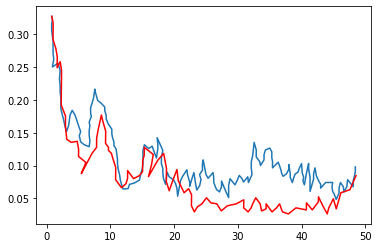

In [3]:
import matplotlib.pyplot as plt

plt.plot(coh_control[:, 0], coh_control[:, 1])
plt.plot(coh_cereboff[:, 0], coh_cereboff[:, 1], 'r')

In [4]:
[coh_control[:,0].min(), coh_control[:,0].max(), np.diff(coh_control[:,0]).mean(), np.diff(coh_control[:,0]).std()]

[0.7777777777777768,
 48.44444444444444,
 0.2313915857605178,
 0.24353034531444961]

In [5]:
[coh_cereboff[:,0].min(), coh_cereboff[:,0].max(), np.diff(coh_cereboff[:,0]).mean(), np.diff(coh_cereboff[:,0]).std()]

[0.7908653846153815, 48.55288461538462, 0.4592501849112427, 0.452291174839288]

In [6]:
ftarg = np.arange(5.0, 48.0, 1.0)
def interpolate(data, f=ftarg):
    from scipy.interpolate import interp1d

    # Compute coherence interpolation...
    interp = interp1d(data.T[0], data.T[1], kind='linear', axis=0,
                      copy=True, bounds_error=None, fill_value=0.0, assume_sorted=True)
    if f is None:
        f = np.arange(6.0, 48.0, 1.0)
    return interp(f)


In [7]:
COH_control = interpolate(coh_control)
COH_cereboff = interpolate(coh_cereboff)

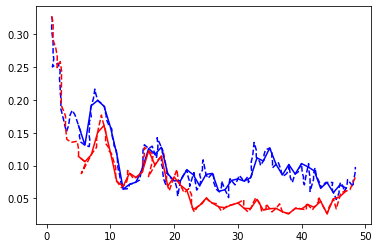

In [8]:
plt.plot(coh_control[:, 0], coh_control[:, 1], 'b--')
plt.plot(coh_cereboff[:, 0], coh_cereboff[:, 1], 'r--')

plt.plot(ftarg, COH_control, "b")
plt.plot(ftarg, COH_cereboff, "r")

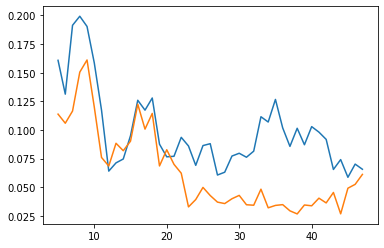

In [9]:
COH = np.vstack([COH_control, COH_cereboff])
COH.shape
plt.plot(ftarg, COH.T)

In [10]:

with open('COH.npy', 'wb') as f:
    np.save(f, COH)

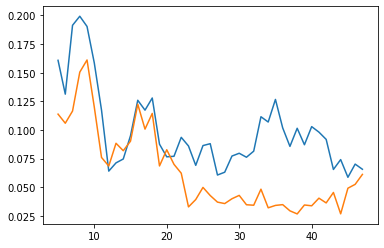

In [11]:
with open('COH.npy', 'rb') as f:
    COH2 = np.load(f)
    
plt.plot(ftarg, COH2.T)

In [12]:
! ls

COH.npy		   PSD_M1.npy	   __init__.py
COH_popa2013.py    PSD_S1.csv	   barplot_PSDbands.csv
COHpopa2013.ipynb  PSD_S1.npy	   coherence_control_Popa2013.csv
PSD_M1.csv	   PS_popa2013.py  coherence_muscimol_Popa2013_Fig3A.csv


In [13]:
PSDM1 = np.load("PSD_M1.npy")
PSDM1int = interpolate(PSDM1)

In [14]:
PSDM1.shape

(115, 2)

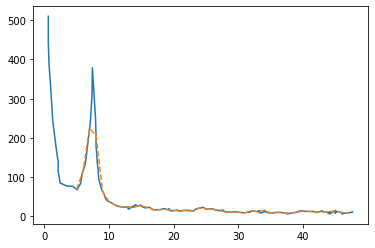

In [15]:
plt.plot(PSDM1[:, 0], PSDM1[:, 1])
plt.plot(ftarg, PSDM1int, "--")

In [16]:
ftarg[0]

5.0

In [17]:
PSDS1 = np.load("PSD_S1.npy")
PSDS1int = interpolate(PSDS1)

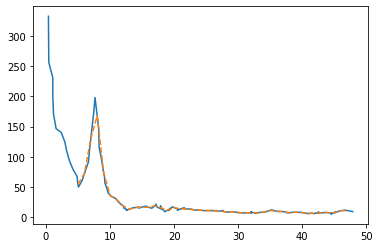

In [18]:
plt.plot(PSDS1[:, 0], PSDS1[:, 1])
plt.plot(ftarg, PSDS1int, "--")

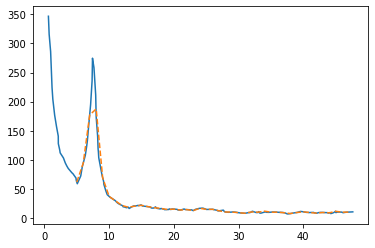

In [19]:
fmin = np.maximum(PSDM1[:, 0].min(), PSDS1[:, 0].min())
fmax = np.minimum(PSDM1[:, 0].max(), PSDS1[:, 0].max())
f = np.sort(PSDM1[:, 0].tolist() + PSDS1[:, 0].tolist())
f = f[np.logical_and(f>=fmin, f<=fmax)]
PSDM1s1 = interpolate(PSDM1, f)
PSDS1m1 = interpolate(PSDS1, f)
plt.plot(f, (PSDM1s1 + PSDS1m1)/2)
plt.plot(ftarg, (PSDM1int + PSDS1int)/2, "--")